CMEMS Dataset https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_MY_008_047/description
Handmatig gedownload vanaf MyOcean Pro, aanklikken punt in de ocean (grof gekozen bij Vlissingen en Ijmuiden) maar informatie in de readme

In [3]:
import pandas as pd
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

csv = r'C:\projecten\RWS\sealevelmonitor\data\copernicus\satellite\cmems_obs-sl_glo_phy-ssh_my_allsat-demo-l4-duacs-0.125deg_P1D-i_1784027499090.csv' #dichtbij ijmuiden
df = pd.read_csv(csv,comment="#")

In [4]:
df = df.rename(columns={'adt':'value'})
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%dT%H:%M:%S.%fZ')

x = (df['time'] - df['time'].iloc[0]).dt.days / 365.25 # years since start
y = df["value"]

result = linregress(x, y)
print(f"Trend = {result.slope:.4f} m/year")


Trend = 0.0039 m/year


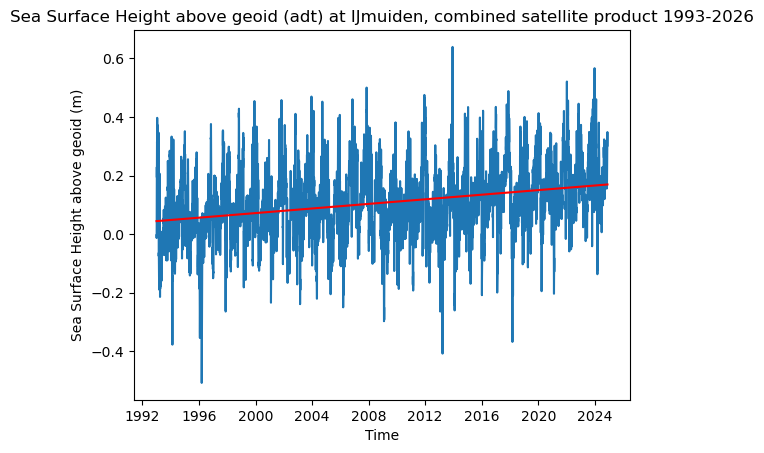

In [5]:
trend = result.intercept + result.slope * x

plt.plot(df['time'], y)
plt.plot(df['time'], trend, color="red")
plt.title("Sea Surface Height above geoid (adt) at IJmuiden, combined satellite product 1993-2026")
plt.xlabel("Time")
plt.ylabel("Sea Surface Height above geoid (m)")
plt.legend(["Observed", "Trend"])
plt.show()

In [6]:
csv = r'C:\projecten\RWS\sealevelmonitor\data\copernicus\satellite\cmems_obs-sl_glo_phy-ssh_my_allsat-demo-l4-duacs-0.125deg_P1D-i_1784027499101.csv' #dichtbij vlissingen
df = pd.read_csv(csv,comment="#")

Trend = 0.0046 m/year


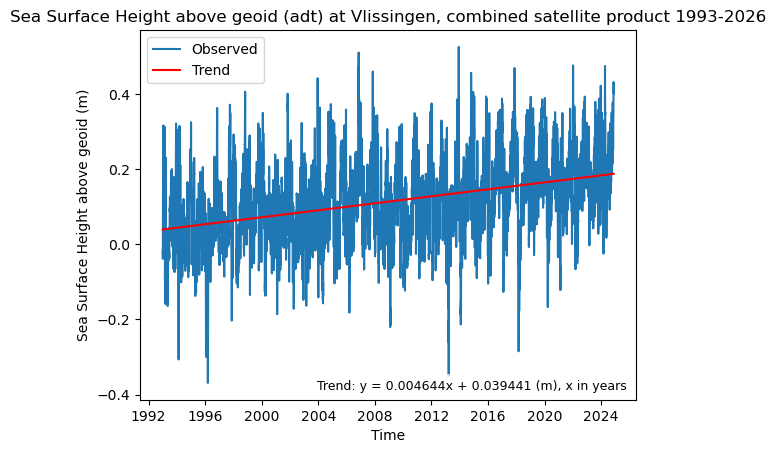

In [10]:
df = df.rename(columns={'adt':'value'})
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%dT%H:%M:%S.%fZ')

x = (df['time'] - df['time'].iloc[0]).dt.days / 365.25 # years since start
y = df["value"]

result = linregress(x, y)
print(f"Trend = {result.slope:.4f} m/year")

trend = result.intercept + result.slope * x
eq_text = f"Trend: y = {result.slope:.6f}x + {result.intercept:.6f} (m), x in years"

ax = plt.gca()
ax.text(
    0.98, 0.02, eq_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

plt.plot(df['time'], y)
plt.plot(df['time'], trend, color="red")
plt.title("Sea Surface Height above geoid (adt) at Vlissingen, combined satellite product 1993-2026")
plt.xlabel("Time")
plt.ylabel("Sea Surface Height above geoid (m)")
plt.legend(["Observed", "Trend"])
plt.show()
